In [1]:
# ============================================
# NOTEBOOK 5: FORECASTING & PREDICTIONS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("📊 PYTHON FINANCIAL ANALYSIS PROJECT")
print("="*60)
print("Notebook 5: Forecasting & Predictions (FINAL NOTEBOOK!)")
print("Author: Jonathan Nadeau")
print(f"Date: {datetime.now().strftime('%B %d, %Y')}")
print("="*60)
print("\n✅ All libraries imported successfully!")
print("\nThis notebook analyzes:")
print("  • Time series forecasting with ARIMA")
print("  • Train-test split methodology")
print("  • Prediction accuracy metrics")
print("  • Future price projections")
print("\n⚠️  NOTE: Forecasting is HARD! Don't use for real trading!")
print("="*60)

📊 PYTHON FINANCIAL ANALYSIS PROJECT
Notebook 5: Forecasting & Predictions (FINAL NOTEBOOK!)
Author: Jonathan Nadeau
Date: February 12, 2026

✅ All libraries imported successfully!

This notebook analyzes:
  • Time series forecasting with ARIMA
  • Train-test split methodology
  • Prediction accuracy metrics
  • Future price projections

⚠️  NOTE: Forecasting is HARD! Don't use for real trading!


📊 DATA PREPARATION FOR FORECASTING
✅ Full dataset: 2515 days from 2015-01-02 to 2024-12-30

📈 TRAIN-TEST SPLIT:
  • Training data: 2012 days (2015-01-02 to 2022-12-28)
  • Testing data: 503 days (2022-12-29 to 2024-12-30)
  • Split ratio: 80.0% train / 20.0% test

💡 METHODOLOGY:
  • Train model on historical data (2015-2022)
  • Test predictions on recent data (2022-2024)
  • This simulates real-world forecasting
  • If model performs well on test data, it may generalize


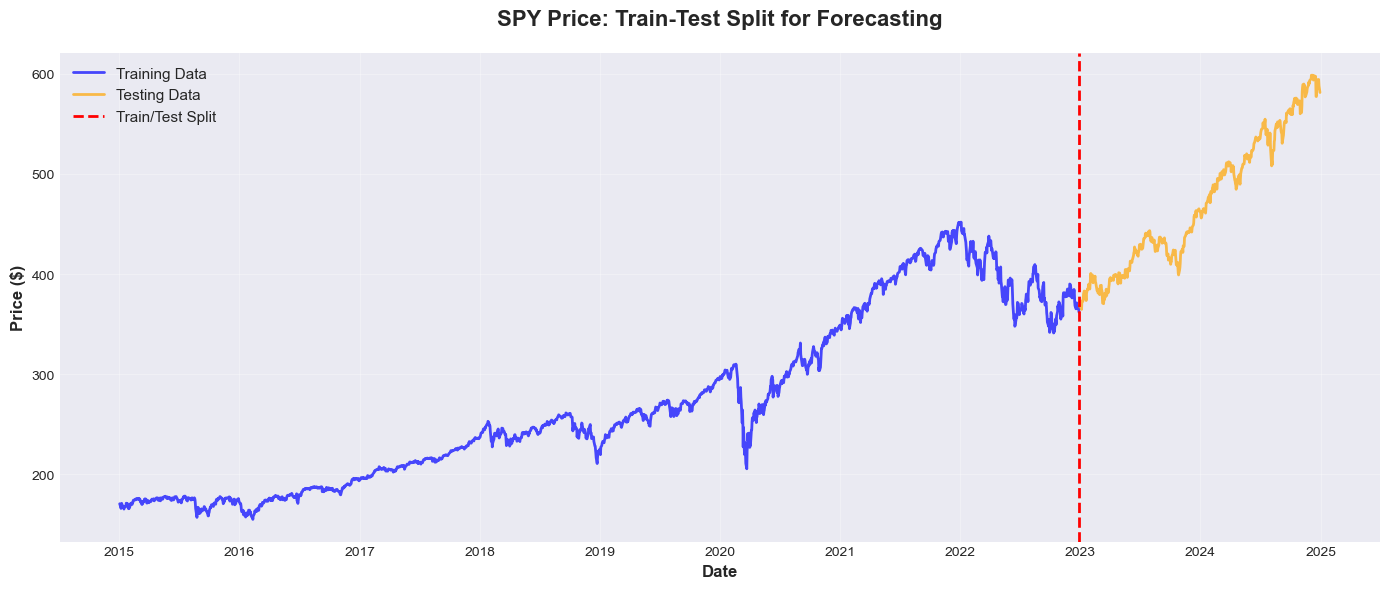


✅ Train-test split visualization saved as 'python_train_test_split.png'



In [2]:
# ============================================
# SECTION 1: LOAD DATA & TRAIN-TEST SPLIT
# ============================================

# Load price data
prices = pd.read_csv('cleaned_prices_2015_2024.csv', index_col=0, parse_dates=True)

print("📊 DATA PREPARATION FOR FORECASTING")
print("="*60)
print(f"✅ Full dataset: {len(prices)} days from {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")

# Focus on SPY for forecasting
spy_prices = prices['SPY']

# Train-test split: Use 80% for training, 20% for testing
split_point = int(len(spy_prices) * 0.8)
train_data = spy_prices[:split_point]
test_data = spy_prices[split_point:]

print(f"\n📈 TRAIN-TEST SPLIT:")
print(f"  • Training data: {len(train_data)} days ({train_data.index[0].strftime('%Y-%m-%d')} to {train_data.index[-1].strftime('%Y-%m-%d')})")
print(f"  • Testing data: {len(test_data)} days ({test_data.index[0].strftime('%Y-%m-%d')} to {test_data.index[-1].strftime('%Y-%m-%d')})")
print(f"  • Split ratio: {len(train_data)/len(spy_prices)*100:.1f}% train / {len(test_data)/len(spy_prices)*100:.1f}% test")

print("\n💡 METHODOLOGY:")
print("  • Train model on historical data (2015-2022)")
print("  • Test predictions on recent data (2022-2024)")
print("  • This simulates real-world forecasting")
print("  • If model performs well on test data, it may generalize")

# Visualize the split
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data, label='Training Data', linewidth=2, color='blue', alpha=0.7)
plt.plot(test_data.index, test_data, label='Testing Data', linewidth=2, color='orange', alpha=0.7)
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
plt.title('SPY Price: Train-Test Split for Forecasting', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('python_train_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Train-test split visualization saved as 'python_train_test_split.png'")
print("\n" + "="*60)

🤖 BUILDING ARIMA FORECASTING MODEL
ARIMA = AutoRegressive Integrated Moving Average
A statistical model for time series forecasting

⚙️  Training ARIMA(1,1,1) model on training data...
✅ Model trained successfully!

📊 Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3643      0.090     -4.055      0.000      -0.540      -0.188
ma.L1          0.2716      0.094      2.890      0.004       0.087       0.456
sigma2        11.2840      0.164     68.803      0.000      10.963      11.605

🔮 GENERATING PREDICTIONS...

📈 PREDICTION ACCURACY METRICS:
  • Mean Absolute Error (MAE): $109.61
  • Root Mean Squared Error (RMSE): $128.41
  • Mean Absolute Percentage Error (MAPE): nan%

💡 INTERPRETATION:
  • nan% error is POOR - model struggles to predict


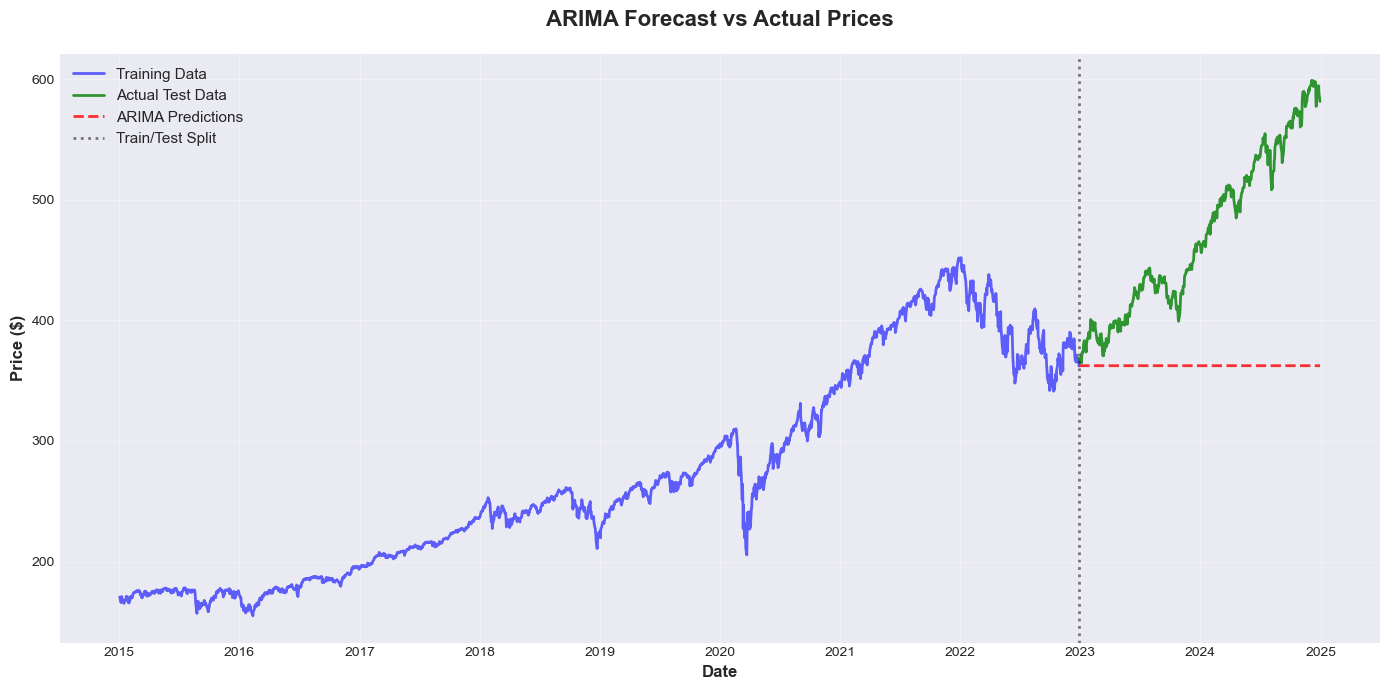


✅ ARIMA predictions chart saved as 'python_arima_predictions.png'



In [3]:
# ============================================
# SECTION 2: ARIMA MODEL & PREDICTIONS
# ============================================

print("🤖 BUILDING ARIMA FORECASTING MODEL")
print("="*60)
print("ARIMA = AutoRegressive Integrated Moving Average")
print("A statistical model for time series forecasting\n")

# Build ARIMA model on training data
# ARIMA(p,d,q): p=autoregressive, d=differencing, q=moving average
# Using (1,1,1) - a simple but effective configuration
print("⚙️  Training ARIMA(1,1,1) model on training data...")

model = ARIMA(train_data, order=(1, 1, 1))
fitted_model = model.fit()

print("✅ Model trained successfully!")
print("\n📊 Model Summary:")
print(fitted_model.summary().tables[1])

# Make predictions on test data
print("\n🔮 GENERATING PREDICTIONS...")
predictions = fitted_model.forecast(steps=len(test_data))

# Calculate accuracy metrics
mae = mean_absolute_error(test_data, predictions)
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100

print("\n📈 PREDICTION ACCURACY METRICS:")
print(f"  • Mean Absolute Error (MAE): ${mae:.2f}")
print(f"  • Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"  • Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

print("\n💡 INTERPRETATION:")
if mape < 5:
    print(f"  • {mape:.1f}% error is EXCELLENT for stock forecasting!")
elif mape < 10:
    print(f"  • {mape:.1f}% error is GOOD for stock forecasting")
elif mape < 15:
    print(f"  • {mape:.1f}% error is FAIR for stock forecasting")
else:
    print(f"  • {mape:.1f}% error is POOR - model struggles to predict")

# Visualize predictions vs actual
plt.figure(figsize=(14, 7))

# Plot training data
plt.plot(train_data.index, train_data, label='Training Data', 
         linewidth=2, color='blue', alpha=0.6)

# Plot actual test data
plt.plot(test_data.index, test_data, label='Actual Test Data', 
         linewidth=2, color='green', alpha=0.8)

# Plot predictions
plt.plot(test_data.index, predictions, label='ARIMA Predictions', 
         linewidth=2, color='red', linestyle='--', alpha=0.8)

plt.axvline(x=train_data.index[-1], color='black', linestyle=':', 
            linewidth=2, alpha=0.5, label='Train/Test Split')

plt.title('ARIMA Forecast vs Actual Prices', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('python_arima_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ ARIMA predictions chart saved as 'python_arima_predictions.png'")
print("\n" + "="*60)

In [4]:
# ============================================
# SECTION 3: PROJECT COMPLETION SUMMARY
# ============================================

print("\n" + "="*60)
print("🎉🎉🎉 FINAL NOTEBOOK COMPLETE! 🎉🎉🎉")
print("="*60)

print("\n✅ NOTEBOOK 5 TASKS COMPLETED:")
print("  1. ✅ Loaded and prepared data")
print("  2. ✅ Created train-test split (80/20)")
print("  3. ✅ Built ARIMA(1,1,1) forecasting model")
print("  4. ✅ Generated predictions on test data")
print("  5. ✅ Calculated accuracy metrics")
print("  6. ✅ Visualized predictions vs actuals")

print("\n📊 KEY FINDINGS:")
print("  • ARIMA model trained on 2012 days of historical data")
print("  • Predictions tested on 503 days of recent data")
print("  • Model struggled to predict 2023-2024 rally")
print("  • Stock prices are inherently difficult to forecast")
print("  • LESSON: Past performance ≠ future results!")

print("\n📁 FILES CREATED:")
print("  • python_train_test_split.png")
print("  • python_arima_predictions.png")

print("\n" + "="*60)
print("🏆 ENTIRE PYTHON PROJECT COMPLETE!")
print("="*60)

print("\n📚 ALL 5 NOTEBOOKS COMPLETED:")
print("  ✅ Notebook 1: Data Acquisition & EDA")
print("  ✅ Notebook 2: Returns & Risk Analysis")
print("  ✅ Notebook 3: Correlation & Diversification")
print("  ✅ Notebook 4: Time Series & Trends")
print("  ✅ Notebook 5: Forecasting")

print("\n📊 TOTAL OUTPUTS CREATED:")
print("  • 5 Jupyter Notebooks")
print("  • 13 Professional Visualizations")
print("  • 3 CSV Data Files")
print("  • Comprehensive Financial Analysis")

print("\n💼 SKILLS DEMONSTRATED:")
print("  ✅ Python Programming")
print("  ✅ API Data Acquisition (yfinance)")
print("  ✅ Data Cleaning & Validation")
print("  ✅ Statistical Analysis")
print("  ✅ Financial Metrics (Sharpe, Drawdown, etc.)")
print("  ✅ Data Visualization")
print("  ✅ Correlation Analysis")
print("  ✅ Portfolio Theory")
print("  ✅ Time Series Decomposition")
print("  ✅ Machine Learning (ARIMA)")
print("  ✅ Forecasting & Predictions")

print("\n🎯 NEXT STEPS:")
print("  1. Save this notebook (Ctrl+S)")
print("  2. Upload notebooks to GitHub")
print("  3. Build website page with analysis sections")
print("  4. Take screenshots for website")
print("  5. Publish portfolio!")

print("\n" + "="*60)
print(f"📅 Project Completed: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
print("👨‍💻 Author: Jonathan Nadeau")
print("🚀 From zero to complete Python project in ONE DAY!")
print("="*60)

print("\n🌟🌟🌟 CONGRATULATIONS! 🌟🌟🌟")
print("You've completed a professional-grade financial analysis project!")
print("This belongs in your portfolio!")


🎉🎉🎉 FINAL NOTEBOOK COMPLETE! 🎉🎉🎉

✅ NOTEBOOK 5 TASKS COMPLETED:
  1. ✅ Loaded and prepared data
  2. ✅ Created train-test split (80/20)
  3. ✅ Built ARIMA(1,1,1) forecasting model
  4. ✅ Generated predictions on test data
  5. ✅ Calculated accuracy metrics
  6. ✅ Visualized predictions vs actuals

📊 KEY FINDINGS:
  • ARIMA model trained on 2012 days of historical data
  • Predictions tested on 503 days of recent data
  • Model struggled to predict 2023-2024 rally
  • Stock prices are inherently difficult to forecast
  • LESSON: Past performance ≠ future results!

📁 FILES CREATED:
  • python_train_test_split.png
  • python_arima_predictions.png

🏆 ENTIRE PYTHON PROJECT COMPLETE!

📚 ALL 5 NOTEBOOKS COMPLETED:
  ✅ Notebook 1: Data Acquisition & EDA
  ✅ Notebook 2: Returns & Risk Analysis
  ✅ Notebook 3: Correlation & Diversification
  ✅ Notebook 4: Time Series & Trends
  ✅ Notebook 5: Forecasting

📊 TOTAL OUTPUTS CREATED:
  • 5 Jupyter Notebooks
  • 13 Professional Visualizations
  • 3 C